In [2]:
import pandas as pd
import numpy as np 
df = pd.read_csv('test.csv')

In [3]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [5]:
df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [6]:
df.Age.describe()

count    332.000000
mean      30.272590
std       14.181209
min        0.170000
25%       21.000000
50%       27.000000
75%       39.000000
max       76.000000
Name: Age, dtype: float64

<Axes: xlabel='Age'>

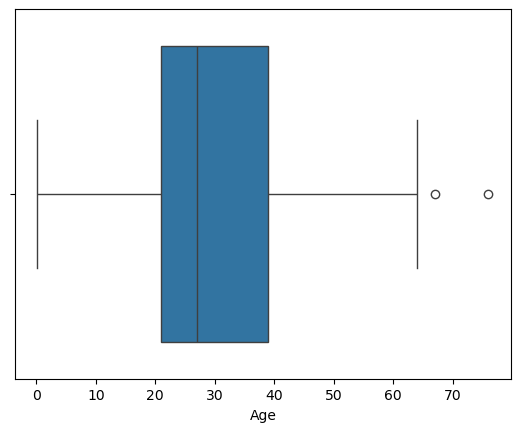

In [7]:
import seaborn as sns
sns.boxplot(x = df['Age'])

In [8]:
df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

In [9]:
df['Age'].isnull().sum()

np.int64(0)

In [12]:
df.Cabin.isnull().sum()

np.int64(327)

In [13]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace = True)

C:\Users\muska\AppData\Local\Temp\ipykernel_3664\1718695086.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0],inplace = True)


In [14]:
df.Embarked.isnull().sum()

np.int64(0)

In [15]:
df['Deck'] = df['Cabin'].str[0]

In [16]:
df['Deck'].isnull().sum()

np.int64(327)

In [ ]:
df.drop('Cabin', axis=1, inplace=True)
df.drop('Deck', axis = 1, inplace = True)
df.drop('PassengerId', axis = 1 , inplace = True)

In [20]:
df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [21]:
df['Name'].head()

0                                Kelly, Mr. James
1                Wilkes, Mrs. James (Ellen Needs)
2                       Myles, Mr. Thomas Francis
3                                Wirz, Mr. Albert
4    Hirvonen, Mrs. Alexander (Helga E Lindqvist)
Name: Name, dtype: object

In [22]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [23]:
df['Title'].value_counts()

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [26]:
df['Title'] = df['Title'].replace(['Mlle'], 'Miss')
df['Title'] = df['Title'].replace(['Mme'], 'Mrs')
df['Title'] = df['Title'].replace(['Ms'], 'Miss')
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Dona','Dr', 'Major', 'Rev', 'Sir', 'Jonkheer']

df['Title'] = df['Title'].replace(rare_titles, 'Rare')


In [27]:
df['Title'].value_counts()

Title
Mr        240
Miss       79
Mrs        72
Master     21
Rare        6
Name: count, dtype: int64

In [28]:
df.drop('Name', axis=1, inplace=True)

In [29]:
df['Ticket'].nunique()

363

In [30]:
df.drop('Ticket', axis=1, inplace=True)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    object 
 2   Age       418 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      417 non-null    float64
 6   Embarked  418 non-null    object 
 7   Title     418 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 26.3+ KB


# Encoding the column to binary format

In [32]:
df = pd.get_dummies(df, columns= ['Sex'], drop_first= True) # this is one hot mapping 

In [33]:
df['Sex_male'] = df['Sex_male'].astype(int)  # this is use to convert the boolean to int for better understanding 

In [34]:
df = pd.get_dummies(df, columns=['Embarked', 'Title'], drop_first=True)

In [35]:
df

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,34.5,0,0,7.8292,1,True,False,False,True,False,False
1,3,47.0,1,0,7.0000,0,False,True,False,False,True,False
2,2,62.0,0,0,9.6875,1,True,False,False,True,False,False
3,3,27.0,0,0,8.6625,1,False,True,False,True,False,False
4,3,22.0,1,1,12.2875,0,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
413,3,24.0,0,0,8.0500,1,False,True,False,True,False,False
414,1,39.0,0,0,108.9000,0,False,False,False,False,False,True
415,3,38.5,0,0,7.2500,1,False,True,False,True,False,False
416,3,24.0,0,0,8.0500,1,False,True,False,True,False,False


In [36]:
bool_cols = df.select_dtypes(include = 'bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [37]:
df

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,34.5,0,0,7.8292,1,1,0,0,1,0,0
1,3,47.0,1,0,7.0000,0,0,1,0,0,1,0
2,2,62.0,0,0,9.6875,1,1,0,0,1,0,0
3,3,27.0,0,0,8.6625,1,0,1,0,1,0,0
4,3,22.0,1,1,12.2875,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
413,3,24.0,0,0,8.0500,1,0,1,0,1,0,0
414,1,39.0,0,0,108.9000,0,0,0,0,0,0,1
415,3,38.5,0,0,7.2500,1,0,1,0,1,0,0
416,3,24.0,0,0,8.0500,1,0,1,0,1,0,0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      418 non-null    int64  
 1   Age         418 non-null    float64
 2   SibSp       418 non-null    int64  
 3   Parch       418 non-null    int64  
 4   Fare        417 non-null    float64
 5   Sex_male    418 non-null    int64  
 6   Embarked_Q  418 non-null    int64  
 7   Embarked_S  418 non-null    int64  
 8   Title_Miss  418 non-null    int64  
 9   Title_Mr    418 non-null    int64  
 10  Title_Mrs   418 non-null    int64  
 11  Title_Rare  418 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 39.3 KB
